# FFNN Pre-Lab 1

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


# 2. Visualisation 3D

In [6]:
df = pd.read_csv('data_ffnn_classification3D.txt', sep='\s+')
print(df.head())

         x1        x2        x3  y
0  0.004527  1.426791  3.350133  3
1  1.358103  1.193950  3.073581  3
2  1.372911  0.218337  3.185136  3
3  0.236595  0.281448  3.171573  3
4  0.933744  1.358714  3.198916  3


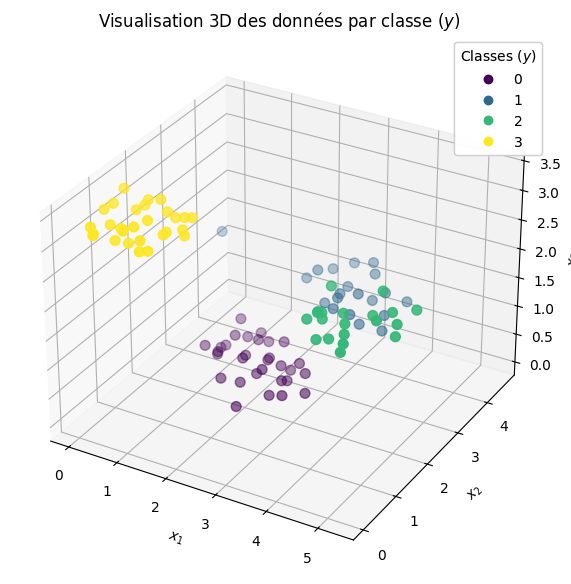

In [7]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['x1'], 
                     df['x2'], 
                     df['x3'], 
                     c=df['y'],      
                     cmap='viridis', 
                     s=50)           

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$x_3$')
plt.title('Visualisation 3D des données par classe ($y$)')

legend = ax.legend(*scatter.legend_elements(), title="Classes ($y$)")
ax.add_artist(legend)

plt.show()

# 3. Feed forward propagation

In [10]:
df.shape

(99, 4)

## Dimension
Parameters:  
- $N = 3$,  
- $I = 99$,  
- $J = 4$,  
- $K = 6$ (TBD)
- $\alpha_1 = \alpha_2 = 10^{-3}$
- $\epsilon = 10^{-2}$

Matrices :  
- $V \in \mathbb{R}^{(N+1) \times K}$
- $W \in \mathbb{R}^{(K+1) \times J}$
- $X \in \mathbb{R}^{I \times N}$
- $\overline{X} \in \mathbb{R}^{I \times (N+1)}$
- $Y \in \mathbb{R}^{I}$

In [116]:
N = df.shape[1] - 1
I = df.shape[0]
J = df['y'].nunique()
K = 6
learning_rate = 0.1 # alpha
epsilon = pow(10,-4) # threshold
iter = 0 # iteration
delta_E = 10000
E = []
E.append(delta_E)

## Random $\theta$ initialisation

In [117]:
rng = np.random.default_rng()

V = rng.random((N+1, K))
W = rng.random((K+1, J))

print(V)

[[0.02752174 0.98120052 0.78565248 0.76181269 0.14161816 0.80060816]
 [0.03330066 0.02137754 0.01799949 0.34370259 0.32856042 0.08037542]
 [0.68970061 0.28810796 0.7511685  0.7287739  0.49299267 0.10747769]
 [0.7836861  0.57016851 0.42007603 0.78189774 0.6232479  0.36374626]]


## Read the data (creation of $X$ and $\overline{X}$)

creation of $X \in \mathbb{R}^{I \times N}$

In [74]:
X = df[['x1','x2','x3']].values
print(X.shape)

(99, 3)


we know that $X_0 = 1$ then we can create $\overline{X} \in \mathbb{R}^{I \times (N+1)}$

In [75]:
X_bar = np.insert(X, 0, 1, axis=1)
print(X_bar.shape)

(99, 4)


## Activation function

In [76]:
def sigmoid(X):
    return 1 / (1 + np.exp(-X))

## Feed Forward Propagation

In [77]:
def fwp(X_bar, F_bar, V, W):
    X_bar_bar = X_bar @ V
    F = sigmoid(X_bar_bar)
    F_bar = np.insert(F, 0, 1, axis=1)
    F_bar_bar = F_bar @ W
    G = sigmoid(F_bar_bar)
    return G, F_bar, F

## One-Hot encoding for the $Y$

We have $Y \in \mathbb{R}^{I}$ and we want to have $Y' \in \mathbb{R}^{I \times J}$

In [92]:
def one_hot_encoding(Y, I, J):
    Y_prime = np.zeros((I, J))
    for i in range(I): 
        value_class = int(Y[i])
        Y_prime[i][value_class] = 1
    return Y_prime

## Error computation

We have the error sucha as  
$$E \triangleq \frac{1}{2} \sum_{i=1}^{I} {\lVert g^{(i)} - y^{(i)} \rVert}_{2}^{2} = \frac{1}{2} \sum_{i=1}^{I} \sum_{j=1}^{J}  ( g^{(i)}_{j} - y^{(i)}_{j} )² $$

We have $G \in \mathbb{R}^{I \times J}$ and $Y' \in \mathbb{R}^{I \times J}$

In [79]:
def error(G, Y_prime, I, J):
    E = 0
    for i in range(I):
        for j in range(J):
            E += pow((G[i][j] - Y_prime[i][j]), 2)
    E = (1/2) * E
    return E

## Back propagation

Derivative of the error are :  
$$ \frac{\partial E}{\partial W_{kj}} = \sum_{i=1}^{I} (g_{j}^{(i)} - y_{j}^{(i)}) g_{j}^{(i)} (1 - g_{j}^{(i)}) f_{k}^{(i)}$$
and we have,  
$$\frac{\partial E}{\partial V_{nk}} = \sum_{i=1}^{I} \sum_{j=1}^{J} (g_{j}^{(i)} - y_{j}^{(i)}) g_{j}^{(i)} (1 - g_{j}^{(i)}) W_{kj} f_{k}^{(i)} (1 - f_{k}^{(i)}) X_{n}^{(i)}$$

In [115]:
def dE_dW_kj(k, j, I, G, Y_prime, F_bar):
    res = 0
    for i in range(I):
        res += (G[i][j] - Y_prime[i][j]) * G[i][j] * (1 - G[i][j]) * F_bar[i][k]
    return res

def dE_dW_nk(n, k, J, I, G, Y_prime, F, X_bar):
    res = 0
    for i in range(I):
        for j in range(J):
            res += (G[i][j] - Y_prime[i][j]) * G[i][j] * (1 - G[i][j]) * W[k+1][j] * F[i][k] * (1-F[i][k]) * X_bar[i][n]
    return res

For $k \in \llbracket 0,K \rrbracket$, $j \in \llbracket 1,J \rrbracket$ :
$$W_{kj}^{(\text{iter})} = W_{kj}^{(\text{iter} - 1)} - \alpha_{1} \frac{\partial E}{\partial W_{kj}^{(\text{iter} - 1)}}$$
And for $n \in \llbracket 0,N \rrbracket$, $k \in \llbracket 1,K \rrbracket$ :
$$V_{nk}^{(\text{iter})} = V_{nk}^{(\text{iter} - 1)} - \alpha_{2} \frac{\partial E}{\partial V_{nk}^{(\text{iter} - 1)}}$$

In [81]:
def back_prop(K, J, N, G, Y_prime, F_bar, F, learning_rate, X_bar, V, W):

    grad_W = np.zeros_like(W)
    grad_V = np.zeros_like(V)

    for k in range(K+1):
        for j in range(J):
            grad_W[k][j] = dE_dW_kj(k,j, I, G, Y_prime, F_bar)

    for n in range(N+1):
        for k in range(K):
            grad_V[n][k] = dE_dW_nk(n, k, J, I, G, Y_prime, F, X_bar)

    W = W - learning_rate * grad_W
    V = V - learning_rate * grad_V
    return V,W

In [124]:
Y_prime = one_hot_encoding(df['y'].values, I, J)
G, F_bar, F = fwp(X_bar, None, V, W)
E = [error(G, Y_prime, I, J)]
delta_E = 100000

while (abs(delta_E) > epsilon):
    old_E = E[-1]
    V, W = back_prop(K, J, N, G, Y_prime, F_bar, F, learning_rate, X_bar, V, W)
    G, F_bar, F = fwp(X_bar, None, V, W)
    current_E = error(G, Y_prime, I, J)
    E.append(current_E)
    delta_E = current_E - old_E
    iter += 1
    #print(f"{iter}, SSE: {current_E}")

## Predictions

For classification problems we have :  
$$\hat{y}_{j}^{(i)} = \underset{j \in [1,\ldots ,J]}{\operatorname{arg\,max}} \, g_{j}^{(i)}$$

In [121]:
def prediction(X, V, W):
    X_bar = np.insert(X,0,1,axis=1)
    G, _, _ = fwp(X_bar, None, V, W)
    predict = np.argmax(G, axis=1)
    return predict, G

In [123]:
X_inference = [[2,	2,	0.15], [3.4,	4,	1],[5.3,	2,	2],[1.3,	1,	3]]
p, g = prediction(X_inference, V,W)
print(p)
print(g)

[0 1 2 3]
[[0.98872926 0.00649911 0.00352934 0.00718598]
 [0.03021063 0.96877376 0.01865791 0.00655921]
 [0.00805675 0.02455971 0.96828955 0.01439309]
 [0.00100351 0.00170695 0.02031005 0.98336375]]
